# Student Starter Notebook

## Goal

Use this notebook to confirm the project environment, load the prepared Criteo splits,
understand the treatment and outcome columns, and establish a clean starting point for
exploratory analysis and uplift modeling.

This notebook does not train or select the final models. The team is expected to build,
evaluate, interpret, and document those models during the project.

## Setup

In Google Colab, clone the repository and move into it before opening this notebook:

```python
!git clone https://github.com/Break-Through-Tech/TBD_Retail-Media-1A-incrementality-modeling-for-privacy-conscious-retail-media.git
%cd TBD_Retail-Media-1A-incrementality-modeling-for-privacy-conscious-retail-media
```

Colab already provides most core packages. Run `!pip install -r requirements.txt` only
when a required import is unavailable.

In [1]:
from pathlib import Path
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import sklift

RANDOM_SEED = 2026
FEATURE_COLUMNS = [f"f{i}" for i in range(12)]
SPECIAL_COLUMNS = ["treatment", "conversion", "visit", "exposure"]
EXPECTED_COLUMNS = FEATURE_COLUMNS + SPECIAL_COLUMNS

sns.set_theme(style="whitegrid")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"scikit-uplift: {sklift.__version__}")

Python: 3.9.6
pandas: 2.3.3
NumPy: 2.0.2
scikit-learn: 1.6.1
scikit-uplift: 0.5.1


## Steps

### 1. Locate And Load The Prepared Data

The path logic works when the notebook is run from the repository root or from the
`notebooks` folder.

In [2]:
if Path("data").is_dir():
    DATA_DIR = Path("data")
elif Path("../data").is_dir():
    DATA_DIR = Path("../data")
else:
    raise FileNotFoundError(
        "Could not find the data folder. Clone the repository and run the notebook "
        "from the repository root or notebooks folder."
    )

split_paths = {
    "train": DATA_DIR / "train.csv.gz",
    "validation": DATA_DIR / "validation.csv.gz",
    "test": DATA_DIR / "test.csv.gz",
}

missing_files = [str(path) for path in split_paths.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing prepared files: {missing_files}")

splits = {name: pd.read_csv(path) for name, path in split_paths.items()}
train = splits["train"]
validation = splits["validation"]
test = splits["test"]

pd.DataFrame(
    {
        "split": list(splits),
        "rows": [len(frame) for frame in splits.values()],
        "columns": [frame.shape[1] for frame in splits.values()],
    }
)

,split,rows,columns
0,train,700000,16
1,validation,150000,16
2,test,150000,16


### 2. Validate Schema And Values

In [3]:
expected_rows = {"train": 700_000, "validation": 150_000, "test": 150_000}

for name, frame in splits.items():
    assert frame.columns.tolist() == EXPECTED_COLUMNS, f"Unexpected columns in {name}"
    assert len(frame) == expected_rows[name], f"Unexpected row count in {name}"
    assert not frame.isna().any().any(), f"Missing values found in {name}"
    for column in SPECIAL_COLUMNS:
        assert set(frame[column].unique()).issubset({0, 1}), (
            f"Unexpected values in {name}.{column}"
        )

print("Schema, row-count, missing-value, and binary-value checks passed.")

Schema, row-count, missing-value, and binary-value checks passed.


### 3. Review Treatment And Outcome Rates

`treatment` is randomized assignment and defines the primary treatment and control groups.
`visit` is the primary outcome. `conversion` is an optional secondary outcome because it is
much rarer. `exposure` happens after assignment and must not be used as a normal audience
feature or as a filter for the primary analysis.

In [4]:
rate_rows = []
for name, frame in splits.items():
    rate_rows.append(
        {
            "split": name,
            "rows": len(frame),
            "treatment_rate": frame["treatment"].mean(),
            "visit_rate": frame["visit"].mean(),
            "conversion_rate": frame["conversion"].mean(),
            "exposure_rate": frame["exposure"].mean(),
        }
    )

split_rates = pd.DataFrame(rate_rows).set_index("split")
split_rates.round(6)

,rows,treatment_rate,visit_rate,conversion_rate,exposure_rate
split,,,,,
train,700000,0.849953,0.046939,0.002839,0.030480
validation,150000,0.849953,0.046940,0.002840,0.031060
test,150000,0.849953,0.046940,0.002840,0.030653


In [5]:
treatment_summary = (
    train.groupby("treatment")["visit"]
    .agg(records="size", visits="sum", visit_rate="mean")
    .rename(index={0: "control", 1: "treatment"})
)
treatment_summary

,records,visits,visit_rate
treatment,,,
control,105033,4066,0.038712
treatment,594967,28791,0.048391


Overall training-split visit uplift: 0.968%


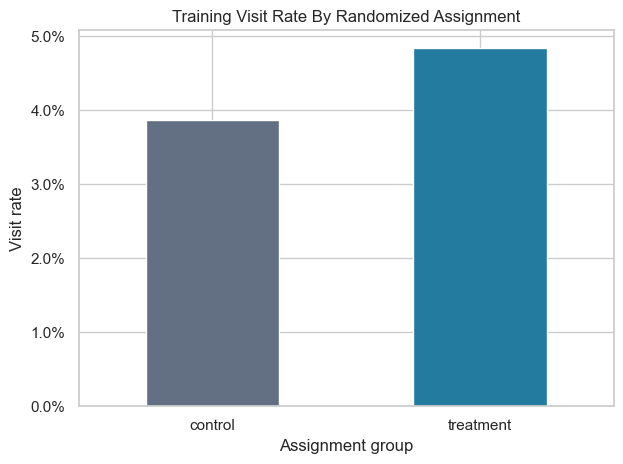

In [6]:
intention_to_treat_lift = (
    treatment_summary.loc["treatment", "visit_rate"]
    - treatment_summary.loc["control", "visit_rate"]
)
print(f"Overall training-split visit uplift: {intention_to_treat_lift:.3%}")

ax = treatment_summary["visit_rate"].plot(
    kind="bar",
    color=["#637083", "#247BA0"],
    title="Training Visit Rate By Randomized Assignment",
    ylabel="Visit rate",
    xlabel="Assignment group",
    rot=0,
)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

### 4. Inspect The Anonymized Features

In [7]:
feature_summary = train[FEATURE_COLUMNS].describe().T
feature_summary[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
f0,19.615798,5.377562,12.616365,12.616365,21.920610,24.426941,26.745247
f1,10.069908,0.103942,10.059654,10.059654,10.059654,10.059654,15.450607
f2,8.446038,0.299195,8.214383,8.214383,8.214383,8.719660,9.051961
f3,4.179534,1.333579,-6.554029,4.679882,4.679882,4.679882,4.679882
f4,10.338691,0.341311,10.280525,10.280525,10.280525,10.280525,20.261471
f5,4.029126,0.426800,-7.549559,4.115453,4.115453,4.115453,4.115453
f6,-4.153383,4.569626,-29.219854,-6.699321,-2.411115,0.294443,0.294443
f7,5.101383,1.204616,4.833815,4.833815,4.833815,4.833815,11.998385
f8,3.933603,0.056650,3.644043,3.910792,3.971858,3.971858,3.971858
f9,16.036083,7.029718,13.190056,13.190056,13.190056,13.190056,68.701147


### 5. Prepare Modeling Inputs

Only `f0` through `f11` are eligible audience model features. Keep treatment assignment and
outcomes separate. Do not use `exposure` as a model feature.

In [8]:
X_train = train[FEATURE_COLUMNS].copy()
treatment_train = train["treatment"].copy()
visit_train = train["visit"].copy()

treatment_probability = treatment_train.mean()
transformed_visit = visit_train * (
    (treatment_train - treatment_probability)
    / (treatment_probability * (1 - treatment_probability))
)

print(f"Training treatment probability: {treatment_probability:.4f}")
print(f"Modeling matrix shape: {X_train.shape}")
print(f"Transformed-outcome mean: {transformed_visit.mean():.6f}")

Training treatment probability: 0.8500
Modeling matrix shape: (700000, 12)
Transformed-outcome mean: 0.009679


## Checks

Before comparing models, confirm that your workflow:

- Uses only `f0` through `f11` as audience features
- Treats randomized assignment as the treatment definition
- Keeps validation and test data out of model training
- Uses `visit` as the primary outcome
- Does not filter the primary analysis to `exposure = 1`
- Reports treatment and control counts inside every evaluation group
- Uses deterministic tie handling before creating ranked audience groups
- Reports uncertainty instead of declaring a winner from very small differences

In [9]:
assert list(X_train.columns) == FEATURE_COLUMNS
assert "exposure" not in X_train.columns
assert 0 < treatment_probability < 1
assert np.isfinite(transformed_visit).all()

print("Starter modeling inputs and leakage guardrails passed.")

Starter modeling inputs and leakage guardrails passed.


## Next Steps

1. Build a random-ranking baseline.
2. Build a conventional response model using treatment records only.
3. Build a T-learner with separate treatment and control models.
4. Build a transformed-outcome model using the training treatment probability.
5. Compare approaches on validation data using ranked-group uplift and uncertainty.
6. Use the test split once for the final selected analysis.
7. Explain what the aggregate findings mean and what this dataset cannot establish about a
   production data clean room.